In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
# 이미지 두 개 로드 (같은 크기로 resize)
img1 = cv2.imread('image.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('image1.png', cv2.IMREAD_GRAYSCALE)
img1 = cv2.resize(img1, (224, 224))
img2 = cv2.resize(img2, (224, 224))

In [3]:
# DFT (주파수 변환)
def dft_image(img):
    dft = np.fft.fft2(img)              # 2D 푸리에 변환
    dft_shift = np.fft.fftshift(dft)    # 중심을 이미지 중앙으로 이동
    return dft_shift

# IDFT (역변환)
def idft_image(dft_shift):
    f_ishift = np.fft.ifftshift(dft_shift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)         # 복소수 → 실수
    return img_back

In [4]:
# Low Pass Filter 생성
def low_pass_filter(shape, radius):
    mask = np.zeros(shape, np.uint8)
    center = (shape[0]//2, shape[1]//2)
    for i in range(shape[0]):
        for j in range(shape[1]):
            if np.sqrt((i - center[0])**2 + (j - center[1])**2) <= radius:
                mask[i, j] = 1
    return mask

# High Pass Filter 생성 (1 - Low-pass)
def high_pass_filter(shape, radius):
    return 1 - low_pass_filter(shape, radius)

In [5]:
# 주파수 변환
dft1 = dft_image(img1)
dft2 = dft_image(img2)

# 마스크 설정
radius = 10 # 필터 반지름(값이 작을수록 고주파수 성분이 강조됨됨)
low_mask = low_pass_filter(img1.shape, radius)
high_mask = high_pass_filter(img1.shape, radius)

In [6]:
# 고주파 / 저주파 분해
low1 = idft_image(dft1 * low_mask)
high1 = idft_image(dft1 * high_mask)

low2 = idft_image(dft2 * low_mask)
high2 = idft_image(dft2 * high_mask)

# 하이브리드 이미지 생성
hybrid1 = np.clip(high1 + low2, 0, 255)
hybrid2 = np.clip(high2 + low1, 0, 255)

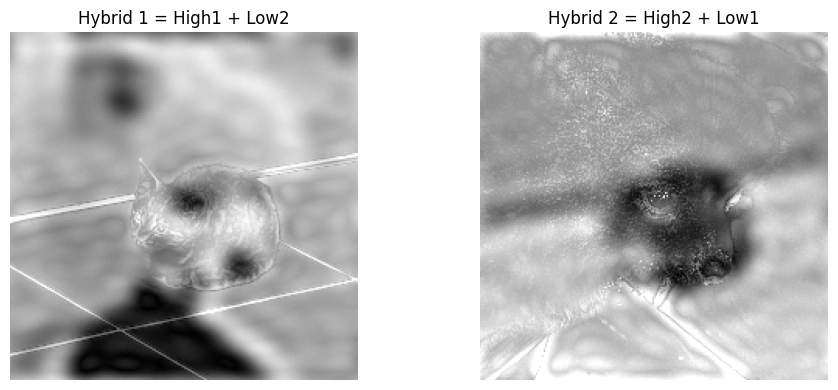

In [7]:
# 하이브리드 결과
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(hybrid1, cmap='gray')
plt.title("Hybrid 1 = High1 + Low2")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hybrid2, cmap='gray')
plt.title("Hybrid 2 = High2 + Low1")
plt.axis('off')

plt.tight_layout()
plt.show()

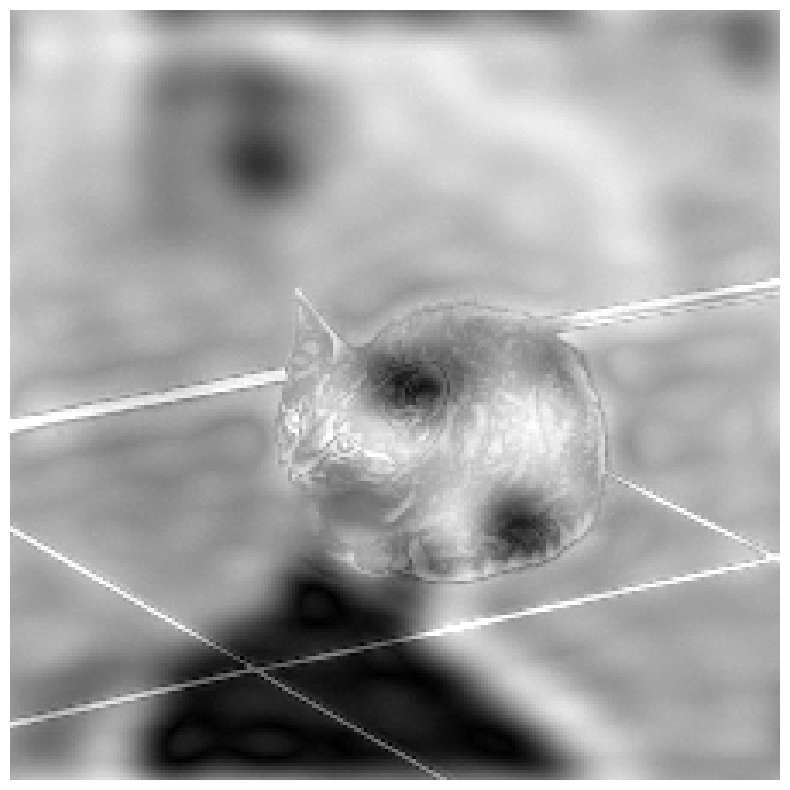

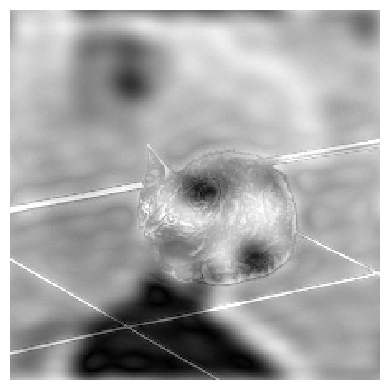

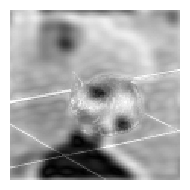

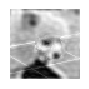

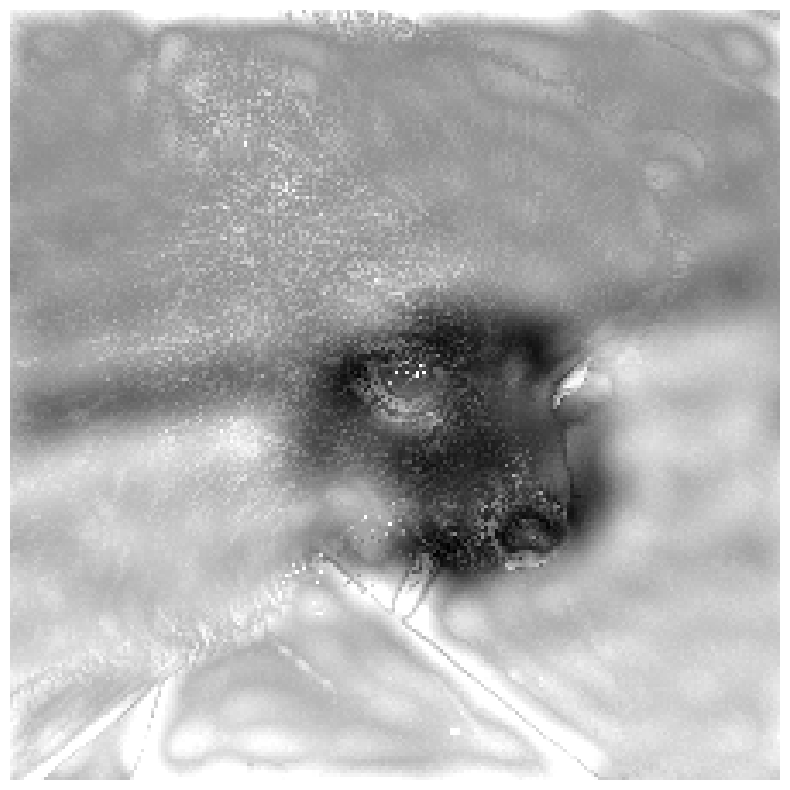

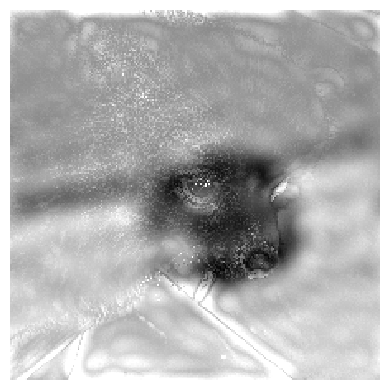

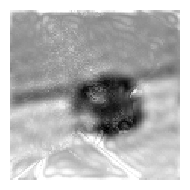

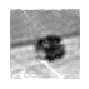

In [8]:
def show_hybrid_individual(image, title, scales=[2.0, 1.0, 0.5, 0.25]):
    for scale in scales:
        resized = cv2.resize(image, (0, 0), fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

        plt.figure(figsize=(scale * 4, scale * 4))  # 이미지가 작아지면 figure도 작아짐
        plt.imshow(resized, cmap='gray', interpolation='nearest')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# Hybrid 이미지 개별 출력
show_hybrid_individual(hybrid1, "Hybrid1")
show_hybrid_individual(hybrid2, "Hybrid2")
